<a href="https://colab.research.google.com/github/ab110404/MAT422/blob/main/HW1.3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

HW 1.3

1.3.1 QR Decomposition

QR decomposition factors a matrix A into two matrices Q and R such that A = QR.

Consider the matrix
A = [[1,1], [1, 0], [0, 1]].

In [2]:
import numpy as np

In [3]:
A = np.array([[1, 1], [1, 0], [0,1]], dtype=float)
print("Matrix A:")
print(A)

Matrix A:
[[1. 1.]
 [1. 0.]
 [0. 1.]]


Finding Q and R

The matrix Q should have orthonormal columns, and R should be an upper triangular matrix

In [4]:
Q, R = np.linalg.qr(A)
print("Matrix Q:")
print(Q)
print("\nMatrix R:")
print(R)

Matrix Q:
[[-0.70710678  0.40824829]
 [-0.70710678 -0.40824829]
 [-0.          0.81649658]]

Matrix R:
[[-1.41421356 -0.70710678]
 [ 0.          1.22474487]]


Verification 1: A = QR

The definition of QR decomposition states that A = QR.

In [5]:
QR = Q @ R
print("Q @ R:")
print(QR)
print("\nOriginal A:")
print(A)

Q @ R:
[[ 1.00000000e+00  1.00000000e+00]
 [ 1.00000000e+00 -1.78835871e-16]
 [ 0.00000000e+00  1.00000000e+00]]

Original A:
[[1. 1.]
 [1. 0.]
 [0. 1.]]


Since the product QR gives the original matrix A, the decomposition A = QR is verified.
Verification 2: Q^TQ = I, for a matrix with orthonormal columns, Q^TQ = I.

In [6]:
QTQ = Q.T @ Q
print("Q^T Q:")
print(QTQ)

Q^T Q:
[[1.00000000e+00 1.02766874e-16]
 [1.02766874e-16 1.00000000e+00]]


The result of Q^TQ is approximately the identity matrix. Therefore, the columns of Q are orthonormal.

Verification 3: R is Upper Triangular
In QR decomposition, R is an upper triangular matrix and an upper triangular matrix has zeros below its main diagonal.

In [7]:
print("Matrix R:")
print(R)

print("\nIs R upper triangular?", np.allclose(R, np.triu(R)))

Matrix R:
[[-1.41421356 -0.70710678]
 [ 0.          1.22474487]]

Is R upper triangular? True


Conclusion:
Multiplying Q and R reproduced the original matrix A, which verified that A = QR. Also, Q^TQ produced the identity matrix and the matrix R was verified to be upper triangular.

1.3.2. Least-squares problems

A least-squares problem is used when a system Ax = b does not have an exact solution.

Example:
A = [[1, 1], [1, 2], [1, 3]] and b = [1, 2, 2]

In [8]:
A = np.array([[1, 1], [1, 2], [1, 3]], dtype=float)
b = np.array([1, 2, 2], dtype=float)

print("Matrix A:")
print(A)
print("\nVector b:")
print(b)

Matrix A:
[[1. 1.]
 [1. 2.]
 [1. 3.]]

Vector b:
[1. 2. 2.]


In [9]:
x, residuals, rank, singular_values = np.linalg.lstsq(A, b, rcond=None)
print("Least-squares solution x:")
print(x)

Least-squares solution x:
[0.66666667 0.5       ]


Now we have to calculate the Approximation Ax:

The least-squares solution does not actually make Ax exactly equal to b. Instead, Ax gives the closest approximation to b that can be produced from the columns of A.

In [10]:
Ax = A @ x
print("Ax:")
print(Ax)
print("\nb:")
print(b)

Ax:
[1.16666667 1.66666667 2.16666667]

b:
[1. 2. 2.]


Residual Vector: the residual measures the difference between the approximation Ax and the original vector b.

r= Ax-b

In [11]:
r = Ax - b
print("Residual vector:")
print(r)

Residual vector:
[ 0.16666667 -0.33333333  0.16666667]


The least-squares solution minimizes the norm ||Ax - b||

In [12]:
residual_norm = np.linalg.norm(r)
print("Residual norm =", residual_norm)

Residual norm = 0.408248290463863


For the least-squares solution, the residual should be orthogonal to the column space of A.

A^Tr = -

In [14]:
orthogonality_check = A.T @ r
print("A^T r:")
print(orthogonality_check)

A^T r:
[2.22044605e-16 8.88178420e-16]


In [15]:
print("Is the residual orthogonal to the columns of A?", np.allclose(A.T @ r, np.zeros(2)))

Is the residual orthogonal to the columns of A? True


Conclusion:

The system Ax = b is overdetermined because there are more equations than unknowns. The residual vector Ax - b is not zero, so there is no exact solution. But the residual norm is minimized. Then A^Tr is approximately zero, which shows that the residual is orthogonal to the column space of A.

1.3.3 Linear Regression

Linear regression is used to find a linear model that best fits a set of data points

Example:
Data points:
x = [1, 2, 3, 4, 5]
y = [2, 4, 5, 4, 6]
I will find the linear regression model 𝑦 = 𝛽0 + 𝛽1x that best fits these data.

In [16]:
x = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([2, 4, 5, 4, 6], dtype=float)
print("x =", x)
print("y =", y)

x = [1. 2. 3. 4. 5.]
y = [2. 4. 5. 4. 6.]


Linear regression can be written as a least-squares problem. The first column of A contains ones for the intercept 𝛽0, and the second column contains the x values. We then find B that minimizes ‖𝐲−𝐴⁢𝜷‖2.

In [17]:
A = np.column_stack((np.ones(len(x)), x))
print("Matrix A:")
print(A)

Matrix A:
[[1. 1.]
 [1. 2.]
 [1. 3.]
 [1. 4.]
 [1. 5.]]


The coefficient vector contains ⁢𝜷 = [⁢𝜷0, ⁢𝜷1]

In [18]:
beta, residuals, rank, singular_values = np.linalg.lstsq(A, y, rcond=None)
beta0 = beta[0]
beta1 = beta[1]
print("𝜷0 =", beta0)
print("𝜷1 =", beta1)

𝜷0 = 1.799999999999998
𝜷1 = 0.8000000000000002


𝜷0 = 1.8 and 𝜷1 = 0.8. Therefore, the fitted linear regression model is y = 1.8 + 0.8x

In [19]:
y_hat = A @ beta
print("Actual y values:")
print(y)
print("\nPredicted y values:")
print(y_hat)

Actual y values:
[2. 4. 5. 4. 6.]

Predicted y values:
[2.6 3.4 4.2 5.  5.8]


The difference between each actual value and predicted value is yi - ^yi. These differences are called residuals.

In [20]:
errors = y - y_hat
print("Residuals:")
print(errors)

Residuals:
[-0.6  0.6  0.8 -1.   0.2]


Linear regression chooses the coefficients that minimize ∑(yi - ^yi)^2

In [21]:
SSE = np.sum(errors**2)
print("Sum of Squared Errors =", SSE)

Sum of Squared Errors = 2.399999999999999


The following graph shows the original data points and the fitted linear regression line.

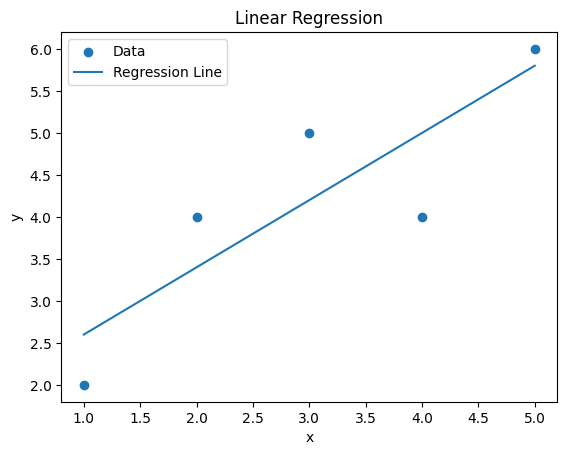

In [22]:
import matplotlib.pyplot as plt

plt.scatter(x, y, label="Data")
plt.plot(x, y_hat, label="Regression Line")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression")
plt.legend()
plt.show()

Conclusion:
The predicted values were calculated using this model, and the differences between the actual and predicted values were used to calculate the sum of squared errors. The sum of squared errors was 2.4. The least-squares regression procedure chooses the coefficients that minimize this quantity.